# LOADING FILES FROM SERVER AND EVALUATE

#### From your WSL terminal (not SCITAS)
cd /path/to/your/local/project

#### Create a directory for the model
mkdir models

#### Download the model checkpoint and training plot
scp -r wan@kuma.hpc.epfl.ch:/home/wan/opp_f/models/ /mnt/c/Users/Jiasheng/OneDrive/Documents/EPFL/ML\ for\ PREDICTIVE\ MAINTENANCE/Project/MLPM/SERVERFILES

#### Load new files to server
scp "/mnt/c/Users/Jiasheng/OneDrive/Documents/EPFL/ML for PREDICTIVE MAINTENANCE/Project/MLPM/SERVERFILES/train.py" wan@kuma.hpc.epfl.ch:/home/wan/opp_f/

In [1]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import os
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from traincae import DEFAULT_PARAMS, CAE, SlidingWindowDataset, Operating_modes_name
from loadData import RawDataset, preprocess_hydraulic_data, preprocess_hydraulic_synthetic_dataset, obtain_ground_truth
import seaborn as sns
import joblib
from matplotlib.gridspec import GridSpec

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
dataset_root = Path(r"../dataset") # Raw string works without escaping \

# CAE TEST

## Loading the traing dataset

In [3]:
# Your existing paths
base_path = Path("./models")
dataset_path = Path("../dataset")
model_path = base_path / "models_VG5_turbine/best_cae_model_VG5_turbine.pth"

# Load scaler_control.pkl from the data folder
with open('data/scaler_VG5_turbine.pkl', 'rb') as file:
    scaler = joblib.load(file)

# Load model and parameters
checkpoint = torch.load(model_path, map_location=device)
DEFAULT_PARAMS = checkpoint['params']

operating_conditions_set = {
    "dyn_only_on": False, "turbine_mode": True, "equilibrium_turbine_mode": True, "short_circuit_mode": False
}

# LOAD PARAMETERS
SYNTHETIC_PARAMS = {
    'unit': 'VG5',
    'test_set': '02',
    'anomaly_type': 'a',
    'set_type':'test_s02'
}

# Load parameters directly from checkpoint
DEFAULT_PARAMS = checkpoint['params']  # This contains all the parameters used during training

training_df = pd.read_parquet('data/training_VG5_turbine.parquet')


# Create dataset for evaluation
train_dataset = SlidingWindowDataset(
    training_df,
    window=DEFAULT_PARAMS['window_size'],
    device=device
)

# Create dataloader
train_loader = DataLoader(
    train_dataset,
    batch_size=DEFAULT_PARAMS['batch_size'],
    shuffle=False  # Important: keep order for anomaly detection
)

# Load your model
model = CAE(
    in_features=len(training_df.columns),
    out_features=len(training_df.columns),
    params=DEFAULT_PARAMS
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()


/tmp/ipykernel_29388/495752842.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


CAE(
  (encoder): Sequential(
    (0): Conv1d(84, 67, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(67, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Conv1d(67, 45, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(45, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Conv1d(45, 22, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): BatchNorm1d(22, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(22, 45, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(45, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): ConvTranspose1d(45, 67, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(67, eps=1e-05, momentum=0.1, affine=True, tra

In [4]:
def reconstruct_signal_from_windows(dataloader, df, model, device):
    """
    Reconstruct the original signals from overlapping windows using the average method.

    Parameters:
    - dataloader: DataLoader object that provides the windows
    - model: Trained PyTorch model for reconstruction
    - device: The device to run the model on (e.g., 'cpu' or 'cuda')

    Returns:
    - reconstructed_signal: The reconstructed signals of shape (num_timesteps, num_channels)
    """
    model.eval()  # Set the model to evaluation mode
    model.to(device)  # Move the model to the specified device
    
    # Get the original data shape from the first batch
    for batch in dataloader:
        _, num_channels, window_size = batch.shape
        break
    
    # Initialize an array to store the reconstructed signals and a count array for averaging
    num_windows = len(dataloader.dataset)
    num_timesteps = (num_windows - 1) + window_size
    reconstructed_signal = np.zeros((num_timesteps, num_channels), dtype=np.float32)
    count = np.zeros((num_timesteps, num_channels), dtype=np.int32)
    
    start_idx = 0

    # Collect the reconstructed windows and accumulate them
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Reconstructing signals"):
            batch = batch.to(device)
            output = model(batch)
            
            if isinstance(output, torch.Tensor):
                output = output.cpu().numpy()
            
            batch_size = output.shape[0]
            for i in range(batch_size):
                end_idx = start_idx + window_size
                reconstructed_signal[start_idx:end_idx, :] += output[i].T
                count[start_idx:end_idx, :] += 1
                start_idx += 1

    # Average the overlapping segments
    reconstructed_signal /= count
    
    return pd.DataFrame(reconstructed_signal,columns=df.columns, index=df.index[:-1])

In [5]:
reconstructed_df = reconstruct_signal_from_windows(train_loader,training_df, model, device)

Reconstructing signals: 100%|██████████| 1298/1298 [01:01<00:00, 21.26it/s]


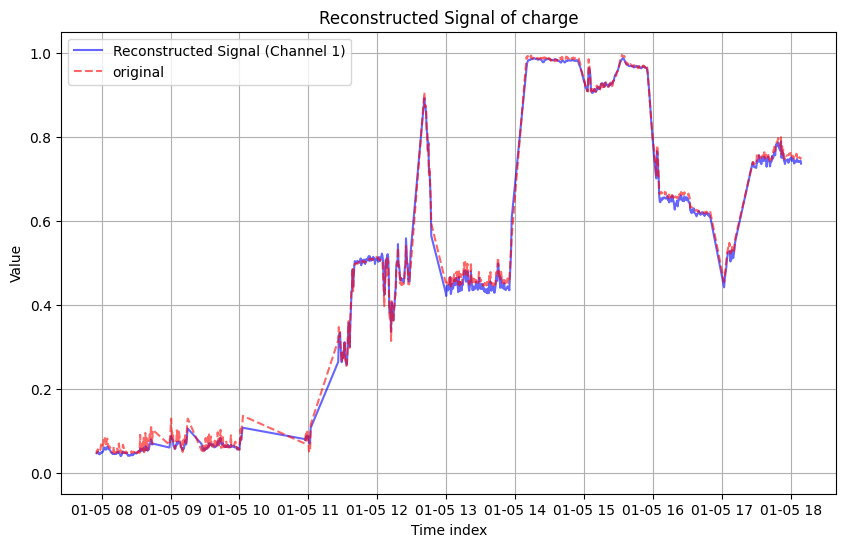

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(reconstructed_df["charge"][100:1000], label='Reconstructed Signal (Channel 1)', color='b', alpha=0.6)
plt.plot(training_df["charge"][100:1000], label="original",  color='r', linestyle='--', alpha=0.6)
plt.xlabel('Time index')
plt.ylabel('Value')
plt.ylim(-0.05,1.05)
plt.title('Reconstructed Signal of charge')
plt.grid()
plt.legend()
plt.savefig("../images/reconstruction_training_VG5_turbine.pdf")
plt.show()

In [24]:
error = np.abs(training_df- reconstructed_df).dropna()

In [68]:
threshold_df = pd.Series(np.quantile(error,0.995,axis=0), index=error.columns)

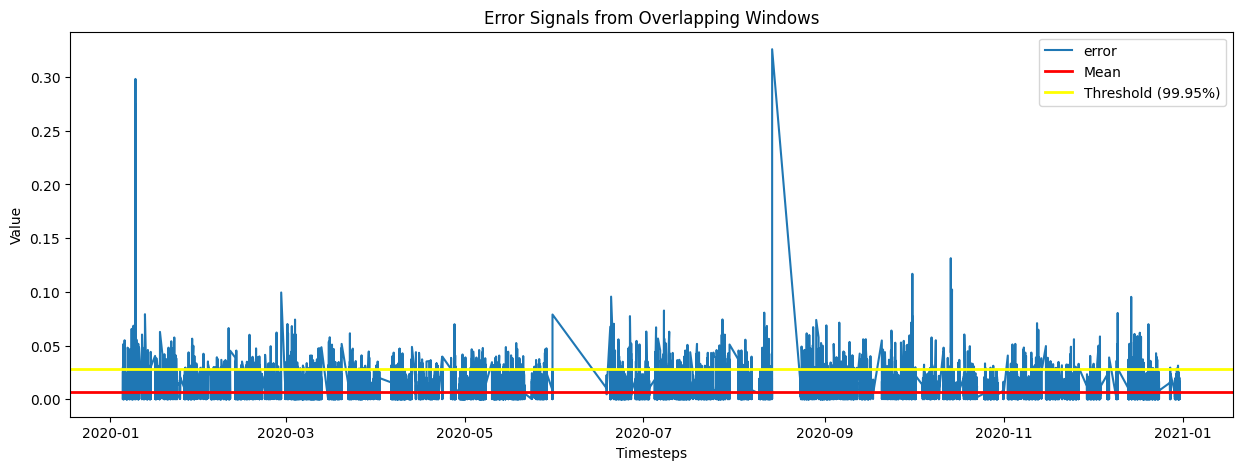

In [151]:
plt.figure(figsize=(15, 5))
plt.plot(error["charge"], label="error")
plt.axhline(np.mean(error["charge"]), color='red', linewidth=2, label="Mean")
threshold = threshold_df["charge"]
plt.axhline(threshold, color='yellow', linewidth=2, label="Threshold (99.95%)")
plt.xlabel('Timesteps')
plt.ylabel('Value')
plt.title('Error Signals from Overlapping Windows')
plt.legend()
plt.show()

### Loading the synthetic dataset

In [139]:

rds_u5_buffer = RawDataset(dataset_path, "VG5", load_synthetic=False, load_training=False)

test_syn_df = preprocess_hydraulic_synthetic_dataset(rds_train=rds_u5_buffer,
                                                     training_df=training_df, 
                                                     unit=SYNTHETIC_PARAMS["unit"],
                                                     number = SYNTHETIC_PARAMS["test_set"],
                                                     Type = SYNTHETIC_PARAMS["anomaly_type"],
                                                     scaler=scaler)


# Create dataset for evaluation
test_dataset = SlidingWindowDataset(
    test_syn_df,
    window=DEFAULT_PARAMS['window_size'],
    device=device
)

# Create dataloader
test_loader = DataLoader(
    test_dataset,
    batch_size=DEFAULT_PARAMS['batch_size'],
    shuffle=False  # Important: keep order for anomaly detection
)


In [140]:
reconstructed_test_df = reconstruct_signal_from_windows(test_loader, test_syn_df, model, device)

Reconstructing signals:   0%|          | 0/219 [00:00<?, ?it/s]

Reconstructing signals: 100%|██████████| 219/219 [00:09<00:00, 22.49it/s]


In [141]:
target_columns = ['water_circ_hot_tmp', 'stat_coil_ph03_05_tmp', 'air_circ_hot_02_tmp']

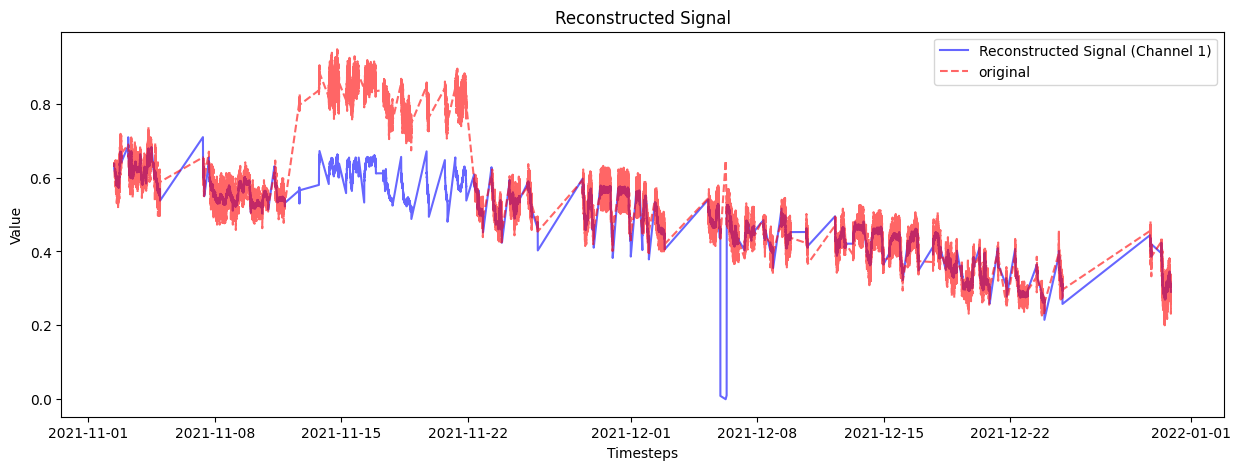

In [142]:
i=0
plt.figure(figsize=(15, 5))
plt.plot(reconstructed_test_df[target_columns[i]], label='Reconstructed Signal (Channel 1)', color='b', alpha=0.6)
plt.plot(test_syn_df[target_columns[i]], label="original",  color='r', linestyle='--', alpha=0.6)
plt.xlabel('Timesteps')
plt.ylabel('Value')
plt.title('Reconstructed Signal')
plt.legend()
plt.show()

In [74]:
error_test = np.abs(test_syn_df- reconstructed_test_df).dropna()

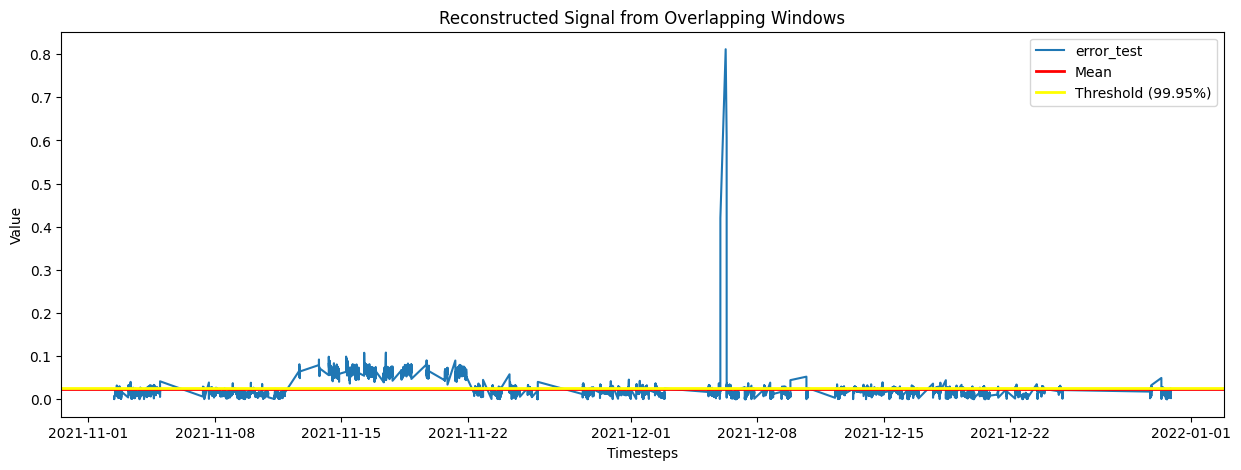

In [75]:
plt.figure(figsize=(15, 5))
plt.plot(error_test[target_columns[i]], label="error_test")
plt.axhline(np.mean(error_test[target_columns[i]]), color='red', linewidth=2, label="Mean")
threshold = threshold_df[target_columns[i]]
plt.axhline(threshold, color='yellow', linewidth=2, label="Threshold (99.95%)")
plt.xlabel('Timesteps')
plt.ylabel('Value')
plt.title('Reconstructed Signal from Overlapping Windows')
plt.legend()
plt.show()

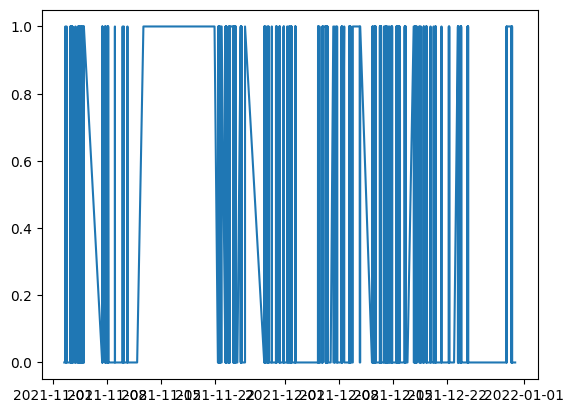

In [76]:
plt.plot(error_test[target_columns[i]] > threshold)

In [93]:
def keep_consecutive_true(series, N):
    """
    Keeps only the consecutive True values in the series if they appear for at least N times.
    
    Parameters:
    - series: A Pandas boolean Series
    - N: The minimum length of consecutive True values to keep
    
    Returns:
    - A Pandas Series where only consecutive True values of length >= N are kept, others are set to False
    """
    # Create an empty series with the same index
    result = pd.Series(False, index=series.index)
    
    # Find the consecutive True values
    consecutive_count = 0
    for i in range(len(series)):
        if series.iloc[i]:  # If current value is True
            consecutive_count += 1
        else:
            consecutive_count = 0
        
        # Keep the True value if the consecutive count is >= N
        if consecutive_count >= N:
            result.iloc[i] = True
    
    return result


In [148]:
Bool_array = keep_consecutive_true(error_test[target_columns[i]] > threshold,130)

dataset_root = '../dataset'
ground_truth,_ = obtain_ground_truth(dataset_root, unit = SYNTHETIC_PARAMS["unit"],
                                     test_set =SYNTHETIC_PARAMS["test_set"],
                                     anomaly_type=SYNTHETIC_PARAMS["anomaly_type"])

ground_truth = ground_truth.loc[ground_truth.index.isin(Bool_array.index)]

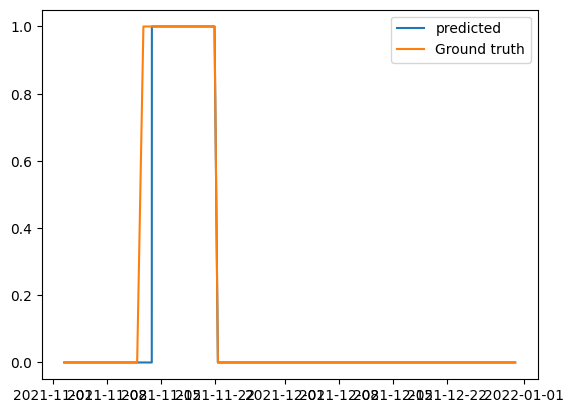

In [150]:

#plt.plot(error_test[target_columns[i]] > threshold)
plt.plot(Bool_array, label="predicted")
plt.plot(ground_truth, label= 'Ground truth')
plt.legend()

In [153]:
threshold_df.to_csv("threshold_test.csv")

In [165]:
def read_threshold(path):
    return pd.read_csv(path, index_col=0)["0"]

threshold_test= read_threshold("threshold_test.csv")